### 2〜6章で使用するサンプルデータの作成

2〜6章で使用するデータセット（本文中で「サンプルデータ」と呼んでいるトイデータ）の作成用スクリプトを解説します。
本データセットは、図2.6に示す、5工程からなる生産ラインでの異常検知を模擬したものです。

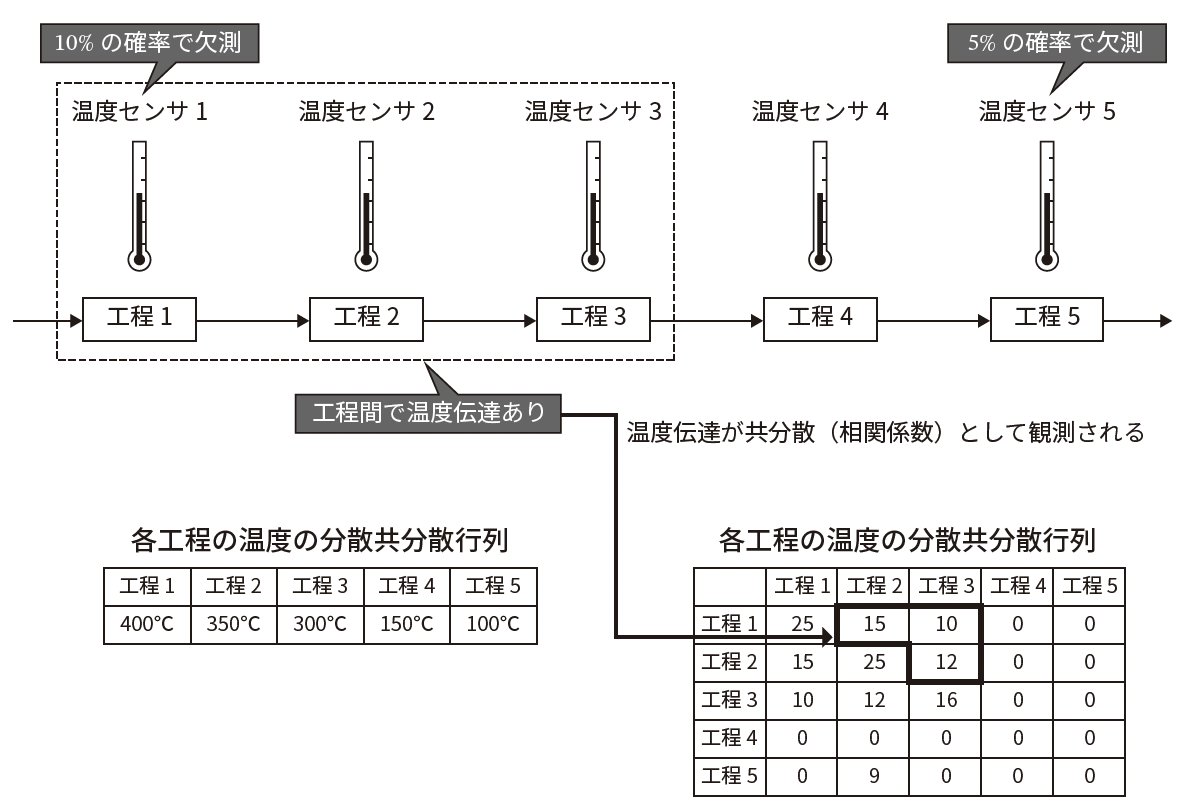

対象となる生産ラインでは、正常時には以下に示す条件の下でデータが測定されています。

- 各工程には温度センサが1つずつ取り付けられている
- 各工程には目標となる温度が存在する（データセット生成時の平均ベクトルに反映）
- データとして測定される温度は、目標温度から正規分布でばらつく（データセット生成時の分散共分散行列に反映）
- 工程1〜3は工程間の距離が近く、温度伝達により温度に相関が生まれる（データセット生成時の分散共分散行列に反映）
- 温度センサ1と温度センサ5は、それぞれ10%および5%の確率で欠測が発生する

また、異常データは、以下のメカニズムで発生するものとします。

- 異常データは、温度調整機能の故障により発生し、データの平均値が一定量（温度センサ2が20°C、1,3 が10°C）ずれる（分散、共分散は変化しない）

これらの前提に基づき、正常データ1500件、異常データ30件を生成し、それぞれ2/3を学習用、1/3を推論用に分割します。
次に示すコードで、上記前提に則ったデータセットを生成できます。

In [1]:
# コード2.23 2〜5 章で使用するサンプルデータの作成
import numpy as np
import pandas as pd

# 正常時の平均（目標温度を模擬）
mu_normal = [400, 350, 300, 150, 100]
# 分散共分散行列（目標温度からのばらつきを模擬）
Sigma = [[25, 15, 10, 0, 0],
         [15, 25, 12, 0, 0],
         [10, 12, 16, 0, 0],
         [ 0, 0, 0, 9, 0],
         [ 0, 0, 0, 0, 9]]
# 乱数シードを指定（結果の再現性を担保する。必須ではない）
rng = np.random.default_rng(seed=42)
# 正常データを模擬した5次元正規分布乱数を1500個生成
n_normal = 1500
normal_dataset = rng.multivariate_normal(mu_normal, Sigma, n_normal)
# 異常データを模擬した5次元正規分布乱数を30個生成
mu_anomaly = [410, 370, 310, 150, 100]
n_anomaly = 30
anomaly_dataset = rng.multivariate_normal(mu_anomaly, Sigma, n_anomaly)

# pandas.DataFrameに変換
df_normal = pd.DataFrame(normal_dataset,
columns=["temp1", "temp2", "temp3", "temp4", "temp5"])
df_anomaly = pd.DataFrame(anomaly_dataset,
columns=["temp1", "temp2", "temp3", "temp4", "temp5"])

# 正常データの欠測値生成
# センサ1の欠測（10%の確率でランダムに発生）
temp1_missed = rng.choice([True, False], n_normal, p=[0.1, 0.9])
df_normal.loc[temp1_missed, "temp1"] = np.nan
# センサ5の欠測（5%の確率でランダムに発生）
temp5_missed = rng.choice([True, False], n_normal, p=[0.05, 0.95])
df_normal.loc[temp5_missed, "temp5"] = np.nan

# 正常データと異常データにラベルを付与する
df_normal["label"] = "normal"
df_anomaly["label"] = "anomaly"

# 学習データと推論データに分ける（2/3が学習用、1/3が推論用）
df_norm_train, df_norm_inference = df_normal[:1000], df_normal[1000:]
df_anom_train, df_anom_inference = df_anomaly[:20], df_anomaly[20:]

# 正常データと異常データを合体させる
df_train = pd.concat([df_norm_train, df_anom_train], axis=0)
df_train = df_train.reset_index(drop=True)
df_inference = pd.concat([df_norm_inference, df_anom_inference], axis=0)
df_inference = df_inference.reset_index(drop=True)

# 作成したデータセットをCSVとして保存
df_train.to_csv("./datasets/ch2_dataset_train.csv", index=False)
df_inference.to_csv("./datasets/ch2_dataset_inference.csv", index=False)